# HW12: временные ряды, temporal split, baseline и GRU

Обязательная часть ДЗ:
- корректный temporal split (`train/validation/test`);
- 4 эксперимента (`B1`, `B2`, `B3`, `R1`);
- выбор лучшего подхода по `validation`;
- один финальный прогон по `test` только для выбранного лучшего подхода;
- сохранение всех обязательных артефактов в `./artifacts/`.


## 1) Импорты, seed, устройство


In [1]:
import json
import random
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BASE_DIR = Path.cwd()
ART_DIR = BASE_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"
ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

Device: cpu


## 2) Данные и первичный анализ


In [2]:
data_path = BASE_DIR / "S12-hw-dataset.csv"
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("rows, cols:", df.shape)
print("date range:", df["date"].min(), "->", df["date"].max())
print("missing by column:")
print(df.isna().sum())
df.head()

rows, cols: (4320, 2)
date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
missing by column:
date      0
target    0
dtype: int64


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


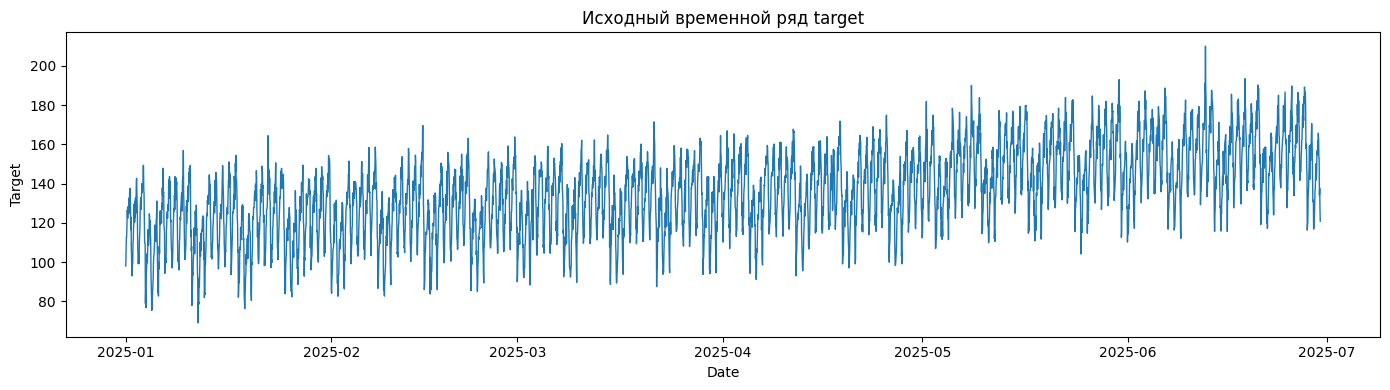

In [3]:
plt.figure(figsize=(14, 4))
plt.plot(df["date"], df["target"], linewidth=1)
plt.title("Исходный временной ряд target")
plt.xlabel("Date")
plt.ylabel("Target")
plt.tight_layout()
plt.show()

Краткий комментарий по ряду: визуально видна выраженная периодичность (внутрисуточные/недельные колебания), при этом есть локальные всплески и смена уровня. Это указывает на потенциальную нестационарность и делает корректный split по времени критичным. Пропусков в исходных колонках нет; пропуски после лагов/rolling будут появляться технически и обрабатываются через `dropna` только после генерации признаков.


## 3) Корректный temporal split


In [4]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("sizes:", len(train_df), len(val_df), len(test_df))
print("train:", train_df["date"].min(), "->", train_df["date"].max())
print("val:  ", val_df["date"].min(), "->", val_df["date"].max())
print("test: ", test_df["date"].min(), "->", test_df["date"].max())

split_summary = (
    f"train:[{train_df['date'].min()}..{train_df['date'].max()}], "
    f"val:[{val_df['date'].min()}..{val_df['date'].max()}], "
    f"test:[{test_df['date'].min()}..{test_df['date'].max()}]"
)
split_summary

sizes: 3024 648 648
train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00
val:   2025-05-07 00:00:00 -> 2025-06-02 23:00:00
test:  2025-06-03 00:00:00 -> 2025-06-29 23:00:00


'train:[2025-01-01 00:00:00..2025-05-06 23:00:00], val:[2025-05-07 00:00:00..2025-06-02 23:00:00], test:[2025-06-03 00:00:00..2025-06-29 23:00:00]'

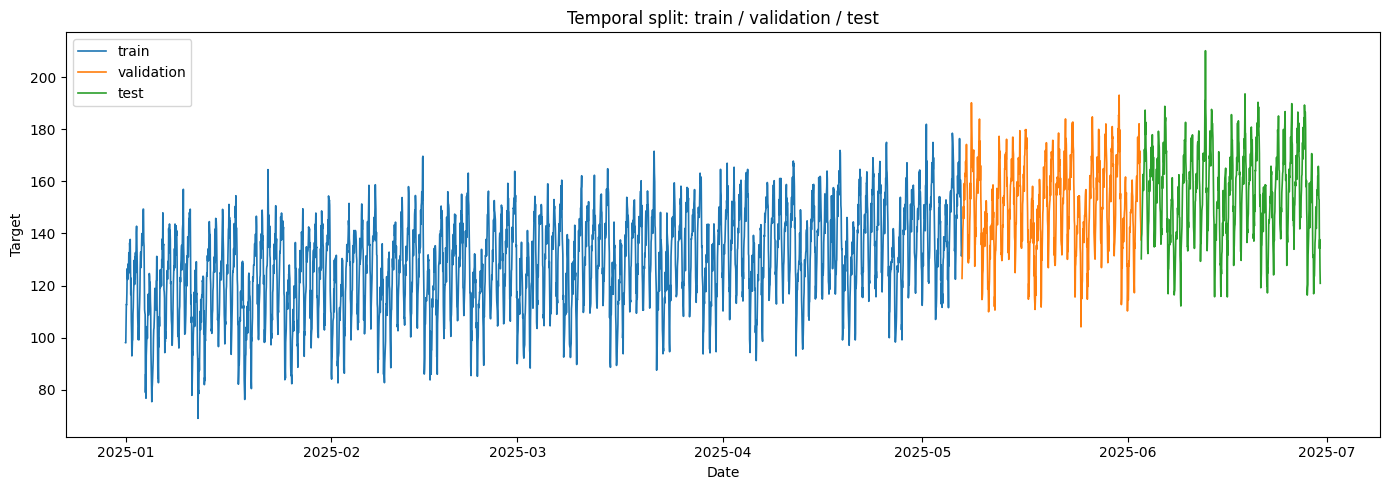

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(train_df["date"], train_df["target"], label="train", linewidth=1.2)
plt.plot(val_df["date"], val_df["target"], label="validation", linewidth=1.2)
plt.plot(test_df["date"], test_df["target"], label="test", linewidth=1.2)
plt.title("Temporal split: train / validation / test")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "series_split.png", dpi=150)
plt.show()

Почему `random split` некорректен: при случайном перемешивании наблюдений модель в обучении видит значения из будущего относительно части валидации/теста, что даёт оптимистичную и нереалистичную оценку. Для временных рядов порядок времени должен быть сохранён.


## 4) Признаки для baseline-моделей


In [6]:
df_feat = df.copy()

# Обязательные лаги
for lag in [1, 7, 14]:
    df_feat[f"lag_{lag}"] = df_feat["target"].shift(lag)

# Обязательные rolling-признаки без утечки (через shift(1))
df_feat["rolling_mean_7"] = df_feat["target"].shift(1).rolling(7).mean()
df_feat["rolling_std_7"] = df_feat["target"].shift(1).rolling(7).std()

# Календарные признаки
# Минимум: день недели. Добавим также hour.
df_feat["day_of_week"] = df_feat["date"].dt.dayofweek
df_feat["hour"] = df_feat["date"].dt.hour

# Технические NaN только из-за лагов/rolling
print("NaN after feature generation:")
print(df_feat.isna().sum())

# Удаляем только строки, где нет сформированных признаков
df_feat = df_feat.dropna().reset_index(drop=True)

feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "hour"
]
feature_cols

NaN after feature generation:
date               0
target             0
lag_1              1
lag_7              7
lag_14            14
rolling_mean_7     7
rolling_std_7      7
day_of_week        0
hour               0
dtype: int64


['lag_1',
 'lag_7',
 'lag_14',
 'rolling_mean_7',
 'rolling_std_7',
 'day_of_week',
 'hour']

In [7]:
train_end_date = train_df["date"].max()
val_end_date = val_df["date"].max()

train_feat = df_feat[df_feat["date"] <= train_end_date].copy()
val_feat = df_feat[(df_feat["date"] > train_end_date) & (df_feat["date"] <= val_end_date)].copy()
test_feat = df_feat[df_feat["date"] > val_end_date].copy()

print("feature split sizes:", len(train_feat), len(val_feat), len(test_feat))

X_train = train_feat[feature_cols].values
y_train = train_feat["target"].values
X_val = val_feat[feature_cols].values
y_val = val_feat["target"].values

x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
print("Scaler fit: train only")

feature split sizes: 3010 648 648
Scaler fit: train only


## 5) Оконное представление для GRU


In [8]:
window_size = 48
horizon = 1

train_targets = train_df["target"].values.reshape(-1, 1)
target_scaler = StandardScaler()
target_scaler.fit(train_targets)  # fit только на train
all_scaled = target_scaler.transform(df[["target"]].values).flatten()

class SequenceDataset(Dataset):
    def __init__(self, series_scaled, start_idx, end_idx, window_size):
        self.series = series_scaled
        self.window_size = window_size
        self.target_indices = np.arange(start_idx, end_idx)

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, idx):
        t = self.target_indices[idx]
        x = self.series[t - self.window_size:t]
        y = self.series[t]
        return (
            torch.tensor(x, dtype=torch.float32).unsqueeze(-1),
            torch.tensor(y, dtype=torch.float32),
        )

train_ds = SequenceDataset(all_scaled, window_size, train_end, window_size)
val_ds = SequenceDataset(all_scaled, train_end, val_end, window_size)
test_ds = SequenceDataset(all_scaled, val_end, len(df), window_size)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
print(len(train_ds), len(val_ds), len(test_ds))

2976 648 648


## 6) Функции обучения и оценки


In [9]:
def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), 1e-8, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def metrics_dict(y_true, y_pred):
    return {
        "mae": mae(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
    }


def inverse_target(values_scaled):
    arr = np.asarray(values_scaled).reshape(-1, 1)
    return target_scaler.inverse_transform(arr).flatten()

## 7) Эксперименты B1, B2, B3, R1


In [10]:
runs = []

def append_run(
    experiment_id,
    model_summary,
    features_summary,
    val_metrics,
    window_size_value=np.nan,
    scaler="",
    optimizer="",
    lr=np.nan,
    epochs_trained=np.nan,
):
    runs.append({
        "experiment_id": experiment_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": window_size_value,
        "horizon": horizon,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": val_metrics["mae"],
        "best_val_rmse": val_metrics["rmse"],
        "best_val_mape": val_metrics["mape"],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "",
    })

# B1: naive-last
val_pred_b1 = df["target"].shift(1).iloc[train_end:val_end]
val_true_b1 = df["target"].iloc[train_end:val_end]
mask = ~val_pred_b1.isna()
val_metrics_b1 = metrics_dict(val_true_b1[mask].values, val_pred_b1[mask].values)
append_run(
    "B1",
    "naive-last",
    "previous target only",
    val_metrics_b1,
)

# B2: moving-average
ma_window = 24
val_pred_b2 = df["target"].shift(1).rolling(ma_window).mean().iloc[train_end:val_end]
val_true_b2 = df["target"].iloc[train_end:val_end]
mask = ~val_pred_b2.isna()
val_metrics_b2 = metrics_dict(val_true_b2[mask].values, val_pred_b2[mask].values)
append_run(
    "B2",
    f"moving-average(window={ma_window})",
    f"rolling mean over last {ma_window} observations",
    val_metrics_b2,
)

# B3: ridge-lag-features
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
val_pred_b3 = ridge.predict(X_val_scaled)
val_metrics_b3 = metrics_dict(y_val, val_pred_b3)
append_run(
    "B3",
    "Ridge(alpha=1.0)",
    ", ".join(feature_cols),
    val_metrics_b3,
    scaler="StandardScaler(features, fit on train)",
)

# R1: gru-forecast
class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

hidden_size = 64
num_layers = 1
dropout = 0.0
max_epochs = 30
patience = 7
lr_gru = 1e-3

model = GRURegressor(1, hidden_size, num_layers, dropout).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr_gru)

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_mae": [],
    "val_rmse": [],
    "val_mape": [],
}

best_state = None
best_val_mae = np.inf
best_epoch = -1
early_stop_counter = 0

for epoch in range(1, max_epochs + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    val_preds_scaled, val_true_scaled = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)

            val_losses.append(loss.item())
            val_preds_scaled.extend(pred.cpu().numpy())
            val_true_scaled.extend(yb.cpu().numpy())

    val_pred_real = inverse_target(val_preds_scaled)
    val_true_real = inverse_target(val_true_scaled)
    val_metrics = metrics_dict(val_true_real, val_pred_real)

    history["epoch"].append(epoch)
    history["train_loss"].append(float(np.mean(train_losses)))
    history["val_loss"].append(float(np.mean(val_losses)))
    history["val_mae"].append(val_metrics["mae"])
    history["val_rmse"].append(val_metrics["rmse"])
    history["val_mape"].append(val_metrics["mape"])

    if val_metrics["mae"] < best_val_mae:
        best_val_mae = val_metrics["mae"]
        best_state = deepcopy(model.state_dict())
        best_epoch = epoch
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            break

if best_state is None:
    best_state = deepcopy(model.state_dict())

model.load_state_dict(best_state)

torch.save(best_state, ART_DIR / "best_gru.pt")

best_gru_config = {
    "model": "GRURegressor",
    "input_size": 1,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "dropout": dropout,
    "window_size": window_size,
    "horizon": horizon,
    "batch_size": batch_size,
    "learning_rate": lr_gru,
    "max_epochs": max_epochs,
    "epochs_trained": len(history["epoch"]),
    "best_epoch": best_epoch,
    "patience": patience,
    "seed": SEED,
    "device": str(device),
    "scaler": "StandardScaler(target, fit on train only)",
}

with open(ART_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

best_i = int(np.argmin(history["val_mae"]))
val_metrics_r1 = {
    "mae": float(history["val_mae"][best_i]),
    "rmse": float(history["val_rmse"][best_i]),
    "mape": float(history["val_mape"][best_i]),
}
append_run(
    "R1",
    f"GRU(hidden={hidden_size}, layers={num_layers})",
    f"windowed target only (window={window_size})",
    val_metrics_r1,
    window_size_value=window_size,
    scaler="StandardScaler(target, fit on train)",
    optimizer="Adam",
    lr=lr_gru,
    epochs_trained=len(history["epoch"]),
)

print(pd.DataFrame(runs)[["experiment_id", "best_val_mae", "best_val_rmse", "best_val_mape"]])

  experiment_id  best_val_mae  best_val_rmse  best_val_mape
0            B1      6.444815       8.201023       4.397922
1            B2     13.397980      16.169904       9.198834
2            B3      6.360191       7.886871       4.282035
3            R1      5.056862       6.601588       3.418348


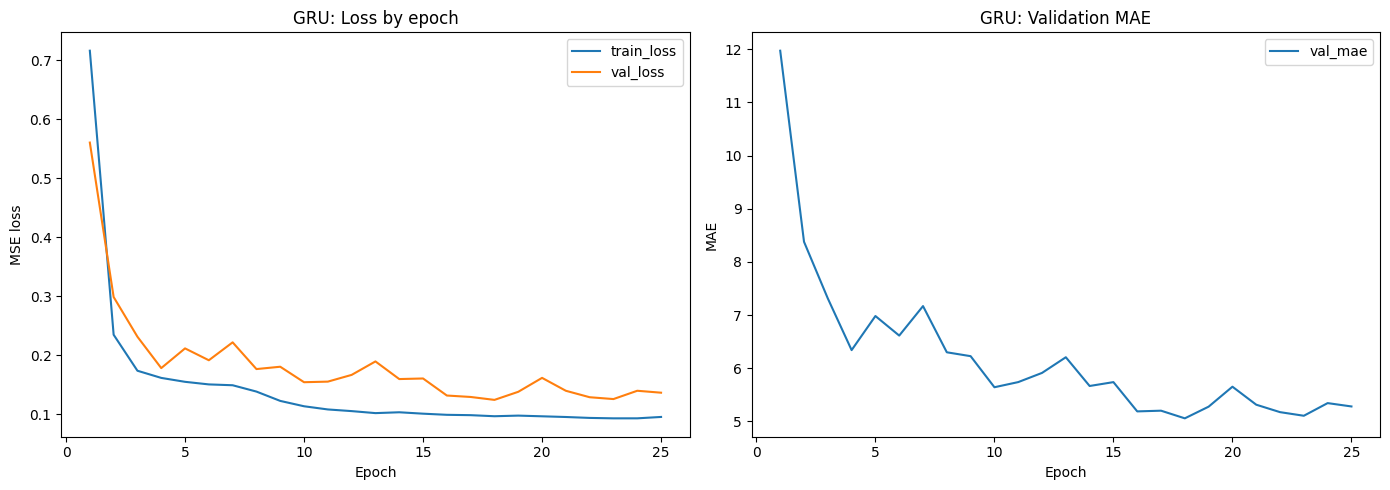

In [11]:
# Кривые обучения GRU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
axes[0].plot(history["epoch"], history["val_loss"], label="val_loss")
axes[0].set_title("GRU: Loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["val_mae"], label="val_mae")
axes[1].set_title("GRU: Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "gru_learning_curves.png", dpi=150)
plt.show()

In [12]:
# Функции прогнозирования на test (вызовется только для лучшего по validation)
def predict_b1_test():
    pred = df["target"].shift(1).iloc[val_end:]
    true = df["target"].iloc[val_end:]
    mask = ~pred.isna()
    return true[mask].values, pred[mask].values, df["date"].iloc[val_end:][mask].values

def predict_b2_test():
    pred = df["target"].shift(1).rolling(ma_window).mean().iloc[val_end:]
    true = df["target"].iloc[val_end:]
    mask = ~pred.isna()
    return true[mask].values, pred[mask].values, df["date"].iloc[val_end:][mask].values

def predict_b3_test():
    X_test = x_scaler.transform(test_feat[feature_cols].values)
    pred = ridge.predict(X_test)
    true = test_feat["target"].values
    dates = test_feat["date"].values
    return true, pred, dates

def predict_r1_test():
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    model.eval()
    pred_scaled, true_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            pred_scaled.extend(pred.cpu().numpy())
            true_scaled.extend(yb.numpy())
    pred = inverse_target(pred_scaled)
    true = inverse_target(true_scaled)
    dates = df["date"].iloc[val_end:].values
    return true, pred, dates

In [13]:
# Выбор лучшей модели по validation и один финальный test
runs_df = pd.DataFrame(runs)

best_idx = runs_df["best_val_mae"].astype(float).idxmin()
best_exp = runs_df.loc[best_idx, "experiment_id"]

if best_exp == "B1":
    y_test_true, y_test_pred, test_dates = predict_b1_test()
elif best_exp == "B2":
    y_test_true, y_test_pred, test_dates = predict_b2_test()
elif best_exp == "B3":
    y_test_true, y_test_pred, test_dates = predict_b3_test()
else:
    y_test_true, y_test_pred, test_dates = predict_r1_test()

best_test_metrics = metrics_dict(y_test_true, y_test_pred)

runs_df.loc[best_idx, "test_mae"] = best_test_metrics["mae"]
runs_df.loc[best_idx, "test_rmse"] = best_test_metrics["rmse"]
runs_df.loc[best_idx, "test_mape"] = best_test_metrics["mape"]
runs_df.loc[best_idx, "notes"] = "Selected by validation MAE; test evaluated once for this model."
runs_df.loc[runs_df.index != best_idx, "notes"] = "No test evaluation (validation-only comparison)."

col_order = [
    "experiment_id", "task", "dataset", "seed", "split_summary", "window_size",
    "horizon", "model_summary", "features_summary", "scaler", "optimizer", "lr",
    "epochs_trained", "best_val_mae", "best_val_rmse", "best_val_mape",
    "test_mae", "test_rmse", "test_mape", "notes",
]
runs_df = runs_df[col_order]
runs_df.to_csv(ART_DIR / "runs.csv", index=False)

print("Best model by validation MAE:", best_exp)
runs_df[["experiment_id", "best_val_mae", "best_val_rmse", "best_val_mape", "test_mae", "test_rmse", "test_mape"]]

Best model by validation MAE: R1


,experiment_id,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape
0,B1,6.444815,8.201023,4.397922,NaN,NaN,NaN
1,B2,13.397980,16.169904,9.198834,NaN,NaN,NaN
2,B3,6.360191,7.886871,4.282035,NaN,NaN,NaN
3,R1,5.056862,6.601588,3.418348,5.603616,7.215382,3.618974


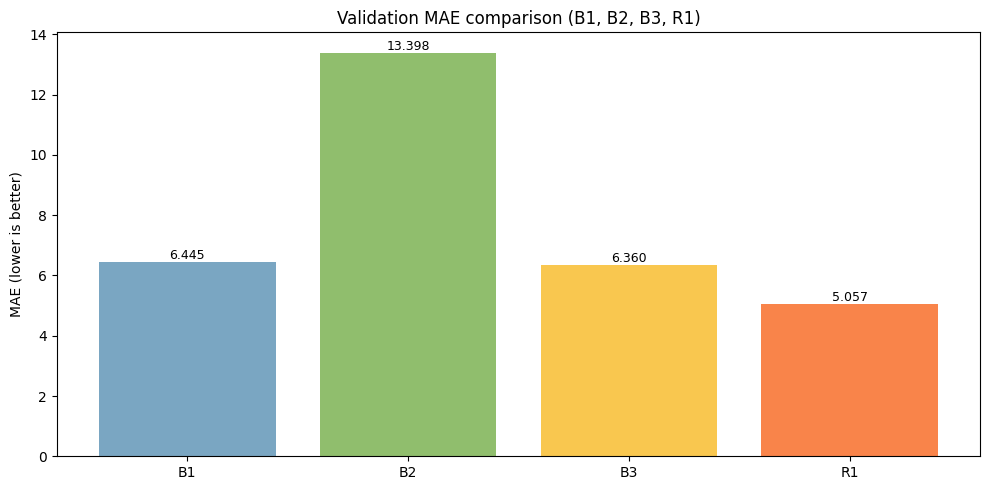

In [14]:
# Сравнение подходов по validation MAE
plot_df = runs_df.copy()
plot_df["best_val_mae"] = plot_df["best_val_mae"].astype(float)

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df["experiment_id"], plot_df["best_val_mae"], color=["#7aa6c2", "#90be6d", "#f9c74f", "#f9844a"])
plt.title("Validation MAE comparison (B1, B2, B3, R1)")
plt.ylabel("MAE (lower is better)")
for bar, value in zip(bars, plot_df["best_val_mae"]):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "baselines_compare.png", dpi=150)
plt.show()

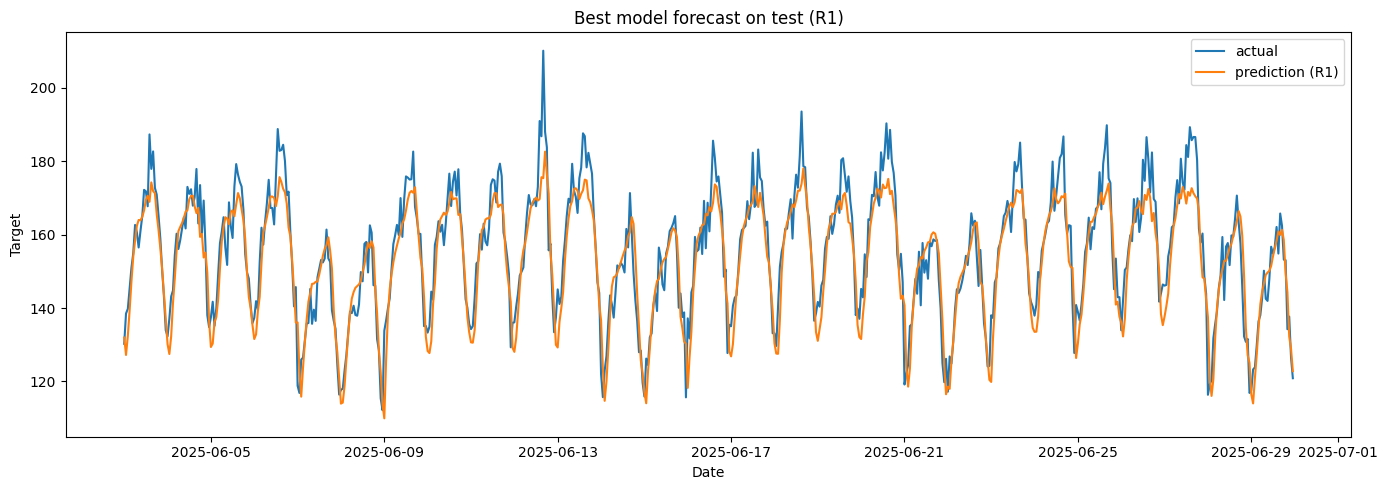

In [15]:
# График факта и прогноза лучшей модели на test
plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test_true, label="actual", linewidth=1.5)
plt.plot(test_dates, y_test_pred, label=f"prediction ({best_exp})", linewidth=1.5)
plt.title(f"Best model forecast on test ({best_exp})")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "best_forecast_test.png", dpi=150)
plt.show()

## 8) Кратко о рисках утечки данных

- Лаговые и rolling-признаки строятся только из прошлого (`shift(1)` перед `rolling`).
- Масштабирование признаков (`B3`) и таргета (`R1`) обучается только на `train`.
- `test` не используется при выборе модели/гиперпараметров; финальная оценка на `test` выполняется один раз для лучшего по `validation`.


## 9) Финальные артефакты

После выполнения `Run All` автоматически сохраняются:
- `./artifacts/runs.csv`
- `./artifacts/best_gru.pt`
- `./artifacts/best_gru_config.json`
- `./artifacts/figures/series_split.png`
- `./artifacts/figures/baselines_compare.png`
- `./artifacts/figures/gru_learning_curves.png`
- `./artifacts/figures/best_forecast_test.png`
